# Indexation des données en tables 
## Exercice randonnée (csv)



Imports utiles à tous les programmes qui suivent.

In [9]:
import csv
import tables

### Programme 1

In [50]:
csv_file = open('rando.csv', "r")
reader = csv.reader(csv_file, delimiter=';')

data = []

for row in reader:
    data.append((row))

liste_entetes = data[0]
parcours = data[1:]

print("liste_entetes = ",liste_entetes)
print("parcours = ",parcours)

liste_entetes =  ['Altitude (m)', 'Distance (m)']
parcours =  [['728', '0'], ['728', '194.67'], ['733', '171.32'], ['724', '128.82'], ['740', '148.06'], ['736', '74.97'], ['728', '121.41'], ['710', '124.03'], ['699', '125.37'], ['695', '108.81'], ['690', '49.72'], ['685', '32.13'], ['678', '31.42'], ['671', '37.33'], ['662', '105.44'], ['657', '103.43'], ['656', '86.72'], ['663', '72.01'], ['674', '85.05'], ['679', '98.53'], ['675', '95.58'], ['678', '78.16'], ['698', '141.14'], ['715', '85.69'], ['720', '34.86'], ['720', '4.23'], ['723', '24.19'], ['725', '31.3'], ['727', '23.1'], ['728', '7.77'], ['729', '10.13'], ['729', '20.9'], ['728', '1.91']]


### Programme 2

In [106]:
def deux_listes():
    csv_file = open('rando.csv', "r")
    reader = csv.reader(csv_file, delimiter=';')

    data=[]

    for row in reader:
        data.append((row))


    distance =[float(data[i][1]) for i in range(1,len(data))]

    altitude =[int(data[i][0]) for i in range(1,len(data))]

    return altitude, distance

print("altitude = ", deux_listes()[0])
print("distance = ", deux_listes()[1])

altitude =  [728, 728, 733, 724, 740, 736, 728, 710, 699, 695, 690, 685, 678, 671, 662, 657, 656, 663, 674, 679, 675, 678, 698, 715, 720, 720, 723, 725, 727, 728, 729, 729, 728]
distance =  [0.0, 194.67, 171.32, 128.82, 148.06, 74.97, 121.41, 124.03, 125.37, 108.81, 49.72, 32.13, 31.42, 37.33, 105.44, 103.43, 86.72, 72.01, 85.05, 98.53, 95.58, 78.16, 141.14, 85.69, 34.86, 4.23, 24.19, 31.3, 23.1, 7.77, 10.13, 20.9, 1.91]


### Programme 3

In [107]:
def denivele():
    positif = 0
    negatif = 0
    altitudes = deux_listes()[0]
    
    for i in range(1, len(altitudes)):
        denivele = altitudes[i] - altitudes[i-1]
        if denivele > 0:
            positif = positif + denivele
        else:
            negatif = negatif - denivele
    return positif, negatif

print("le dénivelé cumulé positif du parcours est de ", denivele()[0], "m")
print("le dénivelé cumulé negatif du parcours est de ", denivele()[1], "m")

le dénivelé cumulé positif du parcours est de  98 m
le dénivelé cumulé negatif du parcours est de  98 m


### Programme 4

In [108]:
def cumul_distance():
    distances = deux_listes()[1]
    distance_parcourue=[distances[0]]
    
    for i in range(1,len(distances)):
        distance_parcourue.append(round(distance_parcourue[-1] + distances[i],2))
    return distance_parcourue

print(cumul_distance())
print("la longueur du parcours est de ", cumul_distance()[-1], "m")

[0.0, 194.67, 365.99, 494.81, 642.87, 717.84, 839.25, 963.28, 1088.65, 1197.46, 1247.18, 1279.31, 1310.73, 1348.06, 1453.5, 1556.93, 1643.65, 1715.66, 1800.71, 1899.24, 1994.82, 2072.98, 2214.12, 2299.81, 2334.67, 2338.9, 2363.09, 2394.39, 2417.49, 2425.26, 2435.39, 2456.29, 2458.2]
la longueur du parcours est de  2458.2 m


### Programme 5

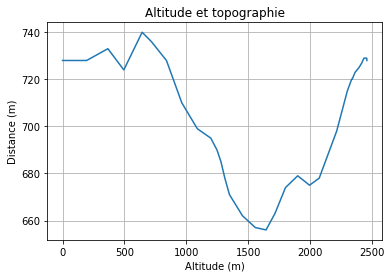

In [109]:
def visualisation_denivele():
    pass
    
from pylab import *

x = array(cumul_distance())
y = array(deux_listes()[0])

title("Altitude et topographie")
xlabel("Altitude (m)")
ylabel("Distance (m)")

plt.grid()

plt.plot(x, y)

plt.show()
    



### Programme 6

In [110]:
import csv
with open('fichier_rando.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile, delimiter=',',
                            quotechar='|', quoting=csv.QUOTE_MINIMAL)
    writer.writerow(['Altitude (m)', 'Distance (m)'])
    
    altitudes = deux_listes()[0]
    distances_cumulees = cumul_distance()
    for i in range(len(altitudes)):
        writer.writerow([distances_cumulees[i], altitudes[i]])